# Data Parsing and Preprocessing

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:

movies = pd.read_csv(
    "data/movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movie_id", "title", "genres"]
)
print(movies)
ratings = pd.read_csv(
    "data/ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
print(ratings)

users = pd.read_csv(
    "data/users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "gender", "age", "occupation", "zip_code" ]
)
print(users)


      movie_id                               title  \
0            1                    Toy Story (1995)   
1            2                      Jumanji (1995)   
2            3             Grumpier Old Men (1995)   
3            4            Waiting to Exhale (1995)   
4            5  Father of the Bride Part II (1995)   
...        ...                                 ...   
3878      3948             Meet the Parents (2000)   
3879      3949          Requiem for a Dream (2000)   
3880      3950                    Tigerland (2000)   
3881      3951             Two Family House (2000)   
3882      3952               Contender, The (2000)   

                            genres  
0      Animation|Children's|Comedy  
1     Adventure|Children's|Fantasy  
2                   Comedy|Romance  
3                     Comedy|Drama  
4                           Comedy  
...                            ...  
3878                        Comedy  
3879                         Drama  
3880              

## Observing the rating distribution

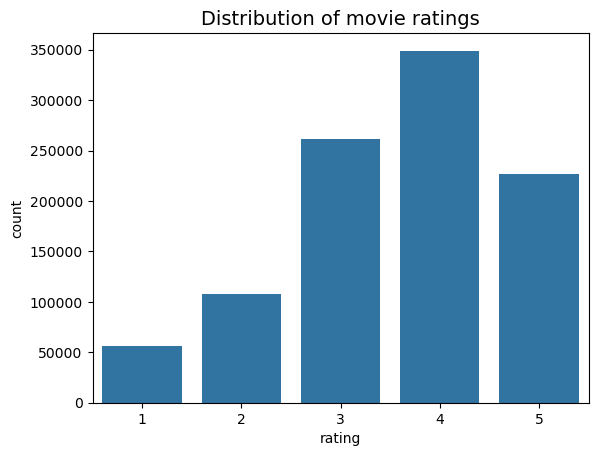

In [31]:
import seaborn as sns
sns.countplot(x="rating", data=ratings)
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

## Merging the data into one table

In [6]:
ratings_movies = pd.merge(movies, ratings, on='movie_id', how='inner')
ratings_movies

,movie_id,title,genres,user_id,rating,timestamp
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,2001-01-06 23:37:48
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,2000-12-31 04:30:08
2,1,Toy Story (1995),Animation|Children's|Comedy,8,4,2000-12-31 03:31:36
3,1,Toy Story (1995),Animation|Children's|Comedy,9,5,2000-12-31 01:25:52
4,1,Toy Story (1995),Animation|Children's|Comedy,10,5,2000-12-31 01:34:34
...,...,...,...,...,...,...
1000204,3952,"Contender, The (2000)",Drama|Thriller,5812,4,2001-06-09 07:34:59
1000205,3952,"Contender, The (2000)",Drama|Thriller,5831,3,2001-04-02 14:52:05
1000206,3952,"Contender, The (2000)",Drama|Thriller,5837,4,2002-01-24 20:04:16
1000207,3952,"Contender, The (2000)",Drama|Thriller,5927,1,2001-01-18 21:15:37


In [13]:
users_movies = pd.merge(ratings_movies, users, on='user_id', how='inner')
users_movies

,movie_id,title,genres,user_id,rating,timestamp,gender,age,occupation,zip_code
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,2001-01-06 23:37:48,F,1,10,48067
1,1,Toy Story (1995),Animation|Children's|Comedy,6,4,2000-12-31 04:30:08,F,50,9,55117
2,1,Toy Story (1995),Animation|Children's|Comedy,8,4,2000-12-31 03:31:36,M,25,12,11413
3,1,Toy Story (1995),Animation|Children's|Comedy,9,5,2000-12-31 01:25:52,M,25,17,61614
4,1,Toy Story (1995),Animation|Children's|Comedy,10,5,2000-12-31 01:34:34,F,35,1,95370
...,...,...,...,...,...,...,...,...,...,...
1000204,3952,"Contender, The (2000)",Drama|Thriller,5812,4,2001-06-09 07:34:59,F,25,7,92120
1000205,3952,"Contender, The (2000)",Drama|Thriller,5831,3,2001-04-02 14:52:05,M,25,1,92120
1000206,3952,"Contender, The (2000)",Drama|Thriller,5837,4,2002-01-24 20:04:16,M,25,7,60607
1000207,3952,"Contender, The (2000)",Drama|Thriller,5927,1,2001-01-18 21:15:37,M,35,14,10003


## Exploring the data

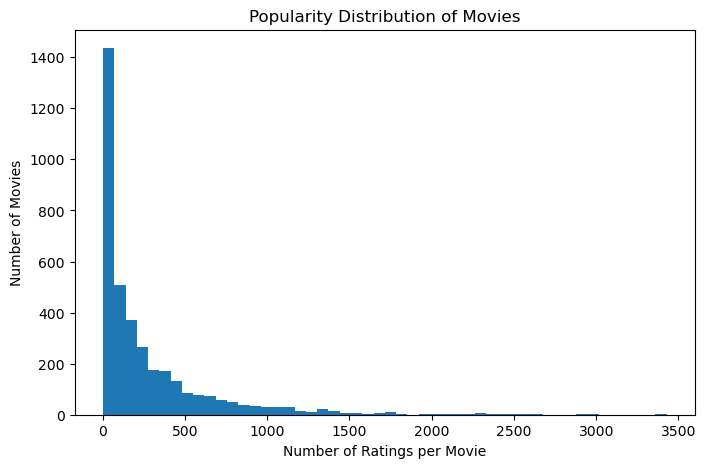

In [19]:
movie_counts = users_movies.groupby("movie_id").size()
plt.figure(figsize=(8,5))
plt.hist(movie_counts, bins=50)
plt.xlabel("Number of Ratings per Movie")
plt.ylabel("Number of Movies")
plt.title("Popularity Distribution of Movies")
plt.show()

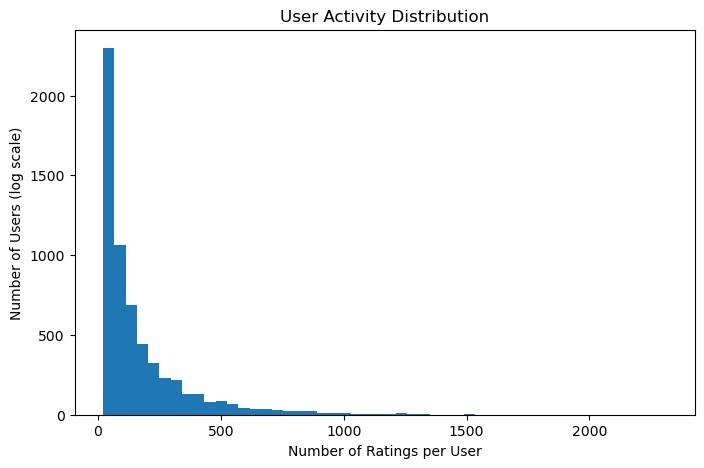

In [23]:
user_counts = users_movies.groupby("user_id").size()

plt.figure(figsize=(8,5))
plt.hist(user_counts, bins=50)
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users (log scale)")
plt.title("User Activity Distribution")
plt.show()

In [12]:
count_mean = users_movies.groupby('movie_id')['rating'].agg(['count', 'mean'])
count_mean.head()

,count,mean
movie_id,,
1,2077,4.146846
2,701,3.201141
3,478,3.016736
4,170,2.729412
5,296,3.006757


## Using Bayesian Average

In [14]:

c = count_mean['count'].mean()
m = count_mean['mean'].mean()

print(f"Average number of ratings for a given movie: {c:.2f}")
print(f"Average rating for a given movie: {m:.2f}")

def avg(ratings):
    avg = (c*m+ratings.sum())/(c+ratings.count())
    return round(avg, 3)

Average number of ratings for a given movie: 269.89
Average rating for a given movie: 3.24


In [16]:
avg_ratings = ratings.groupby('movie_id')['rating'].agg(avg).reset_index()
avg_ratings.columns = ['movie_id', 'avg']
count_mean = count_mean.merge(avg_ratings, on='movie_id')

In [18]:
count_mean = count_mean.merge(movies[['movie_id', 'title']])
count_mean.sort_values('avg', ascending=False).head()

,movie_id,count,mean,avg,title
309,318,2227,4.554558,4.412,"Shawshank Redemption, The (1994)"
802,858,2223,4.524966,4.386,"Godfather, The (1972)"
513,527,2304,4.510417,4.377,Schindler's List (1993)
1108,1198,2514,4.477725,4.358,Raiders of the Lost Ark (1981)
253,260,2991,4.453694,4.353,Star Wars: Episode IV - A New Hope (1977)


In [20]:
count_mean.sort_values('avg', ascending=True).head()

,movie_id,count,mean,avg,title
3353,3593,342,1.611111,2.329,Battlefield Earth (2000)
2496,2701,902,2.158537,2.407,Wild Wild West (1999)
1432,1556,367,1.871935,2.451,Speed 2: Cruise Control (1997)
532,546,350,1.874286,2.468,Super Mario Bros. (1993)
2441,2643,332,1.888554,2.494,Superman IV: The Quest for Peace (1987)


In [22]:
count_mean

,movie_id,count,mean,avg,title
0,1,2077,4.146846,4.042,Toy Story (1995)
1,2,701,3.201141,3.212,Jumanji (1995)
2,3,478,3.016736,3.097,Grumpier Old Men (1995)
3,4,170,2.729412,3.042,Waiting to Exhale (1995)
4,5,296,3.006757,3.117,Father of the Bride Part II (1995)
...,...,...,...,...,...
3701,3948,862,3.635731,3.541,Meet the Parents (2000)
3702,3949,304,4.115132,3.703,Requiem for a Dream (2000)
3703,3950,54,3.666667,3.310,Tigerland (2000)
3704,3951,40,3.900000,3.324,Two Family House (2000)


## Performing a train/test split on the data

In [25]:
train, test = train_test_split(users_movies, test_size=0.2, random_state=42, stratify=users_movies['user_id'])


In [27]:
train.head()

,movie_id,title,genres,user_id,rating,timestamp,gender,age,occupation,zip_code
199509,788,"Nutty Professor, The (1996)",Comedy|Fantasy|Romance|Sci-Fi,4784,3,2000-07-10 18:33:34,F,35,6,48105
270544,1092,Basic Instinct (1992),Mystery|Thriller,4072,4,2000-08-05 05:48:34,M,50,6,93111
466724,1653,Gattaca (1997),Drama|Sci-Fi|Thriller,3134,5,2000-09-16 06:06:35,M,18,4,55455
150752,544,Striking Distance (1993),Action,3217,3,2000-09-12 18:34:07,F,35,0,92630
133465,492,Manhattan Murder Mystery (1993),Comedy|Mystery,887,3,2000-11-26 16:54:28,F,56,16,55345


In [29]:
test.head()

,movie_id,title,genres,user_id,rating,timestamp,gender,age,occupation,zip_code
640806,2369,Desperately Seeking Susan (1985),Comedy|Romance,3201,3,2000-09-10 22:34:58,M,45,7,35216
78976,296,Pulp Fiction (1994),Crime|Drama,4118,5,2000-08-04 03:45:41,M,25,3,91221
178137,648,Mission: Impossible (1996),Action|Adventure|Mystery,1509,3,2000-11-30 19:03:32,M,1,0,11803
641868,2371,Fletch (1985),Comedy,5140,4,2000-07-29 13:46:06,M,25,6,35205
78765,296,Pulp Fiction (1994),Crime|Drama,3557,5,2000-08-20 20:41:28,M,18,5,48185


## Saving the data into CSV files for use

In [31]:
train.to_csv("train.csv", index=False)
test.to_csv("test.csv", index=False)

In [33]:
users_movies.to_csv('users_movies.csv', index=False)